# Tutorial_3_Make_a_R_file

## Example of creating an R file with a flag for tolerance parameters and scale parameters
### This specific example contains JWST NIRSpec and MIRI data

### for further details, read: https://ui.adsabs.harvard.edu/abs/2023ApJ...951L..48B/abstract

In [4]:
import numpy as np
# from jupyterthemes import get_themes
# import jupyterthemes as jt
# from jupyterthemes.stylefx import set_nb_theme
# set_nb_theme('chesterish')
import matplotlib.pyplot as plt
import numpy

In [29]:
# def instrument_R(slit_limited, source_limited, wl, d_wl, resel_slit_lim, nirspec_wl_range, miri_wl_range, D, theta_pix):
#     '''Function that provides the Resolving Power (R) as a function of wavelength (wl) in micron
#        with flags for the tolerance param and scale param,
#        depending on jwst instrument'''
    
#     if slit_limited == 1.0 and source_limited == 0.0:
#         R = wl/(d_wl * resel_slit_lim)
#         log_f_param = np.ones_like(R)
#         scale_param = np.zeros_like(R)
#         return R, wl, log_f_param, scale_param
#     elif source_limited == 1.0 and slit_limited == 0.0:
#         theta_lambda = (648000/np.pi) * 1.028 * (wl/D) #FWHM in arcsec
#         R = wl / (d_wl * (theta_lambda / theta_pix))
#         log_f_param = np.ones_like(R)
#         scale_param = np.zeros_like(R)
#         return R, wl, log_f_param, scale_param
#     elif source_limited == 1.0 and slit_limited == 1.0:
#         ### nirspec
#         nirspec_wl = wl[(wl >= nirspec_wl_range[0]) & (wl <= nirspec_wl_range[1])]
#         nirspec_d_wl = d_wl[(wl >= nirspec_wl_range[0]) & (wl <= nirspec_wl_range[1])]
#         R_nirspec = nirspec_wl/(nirspec_d_wl * resel_slit_lim)
#         theta_lambda_nirspec = (648000/np.pi) * 1.028 * (nirspec_wl/D)
#         #print('theta_lambda_nirspec', theta_lambda_nirspec)
#         log_f_param_nirspec = np.ones_like(R_nirspec)
#         scale_param_nirspec = np.zeros_like(R_nirspec)
#         ### miri
#         miri_wl = wl[(wl >= miri_wl_range[0]) & (wl <= miri_wl_range[1])]
#         miri_d_wl = d_wl[(wl >= miri_wl_range[0]) & (wl <= miri_wl_range[1])]
#         theta_lambda = (648000/np.pi) * 1.028 * (miri_wl/D)
#         #print('theta_lambda_miri', theta_lambda)
#         R_miri = miri_wl / (miri_d_wl * (theta_lambda / theta_pix))
#         #print(np.shape(R_miri),np.shape(R_nirspec))
#         log_f_param_miri = np.full_like(R_miri, 2)
#         if scale == 0.0:
#             scale_param_miri = np.zeros_like(R_miri)
#         else:
#             scale_param_miri = np.ones_like(R_miri)
#         #plt.plot(nirspec_wl,R_nirspec)
#         #plt.plot(miri_wl,R_miri)
#         return np.concatenate((R_nirspec, R_miri)), np.concatenate((nirspec_wl, miri_wl)), np.concatenate((log_f_param_nirspec, log_f_param_miri)), np.concatenate((scale_param_nirspec, scale_param_miri))
#     else:
#         print('Error: incorrect values given for source_limited and slit_limited.')

In [30]:
def R_slit_limited(wl, d_wl, resel_slit_lim):
    R = wl/(d_wl * resel_slit_lim)
    return R


def R_source_limited(wl,D,theta_pix):
    theta_lambda = (648000/np.pi) * 1.028 * (wl/D) #FWHM in arcsec
    R = wl / (d_wl * (theta_lambda / theta_pix))
    return R


In [34]:
obs_data = np.loadtxt('/Users/fw23aao/spidernail/brewster_trail/v2_master/brewster_v2/examples/example_data/G570D_2MHcalib.dat')
print(np.shape(obs_data))

wl =  obs_data[:, 0]  #lambda in microns
d_wl = np.zeros_like(wl)   #pixel width, dispersion
d_wl[1:-1] = (wl[2:] - wl[:-2]) / 2
d_wl[0] = wl[1] - wl[0]
d_wl[-1] = wl[-1] - wl[-2]


(371, 3)


Text(0.5, 0, 'wl')

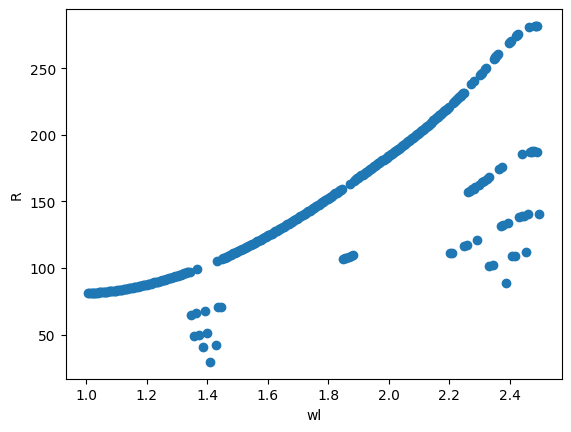

In [35]:
resel_slit_lim = 3.2 
R_G570D= R_slit_limited(wl, d_wl, resel_slit_lim)


log_f_flag = np.ones_like(R_G570D)
scale_flag = np.zeros_like(R_G570D)

plt.scatter(wl,R_G570D)
plt.ylabel('R')
plt.xlabel('wl')

In [33]:
import pandas as pd

df = pd.DataFrame({
    "R_G570D": R_G570D,
    "wl": wl,
    "log_f_flag": log_f_flag,
    "scale_flag": scale_flag
})

print(df.head())

     R_G570D       wl  log_f_flag  scale_flag
0  81.054285  1.00637         1.0         0.0
1  81.262066  1.01025         1.0         0.0
2  81.365533  1.01414         1.0         0.0
3  81.365090  1.01804         1.0         0.0
4  81.366242  1.02196         1.0         0.0


In [ ]:
df.to_csv('examples/example_data/G570D_R_file_fei.txt', sep=' ', index=False,header=False)

In [42]:
obspec= np.loadtxt('data/test_data/Mie_cloud_1800K_model_benchmark_SPEC.dat',skiprows=3,unpack=True)

wl =  obspec[0]  #lambda in microns
d_wl = np.zeros_like(wl)   #pixel width, dispersion
d_wl[1:-1] = (wl[2:] - wl[:-2]) / 2
d_wl[0] = wl[1] - wl[0]
d_wl[-1] = wl[-1] - wl[-2]


In [45]:
band1 = wl[(wl < 2.5)]
band2=wl[(wl >= 2.5) & (wl <= 5)]
band3 = wl[(wl > 5)]

In [64]:
resel_slit_lim=3.3
R1=R_slit_limited(wl[(wl < 2.5)], d_wl[(wl < 2.5)], resel_slit_lim)
R2=np.ones_like(band2)*425
R3=np.ones_like(band3)*100

In [74]:
R=np.concatenate((R1,R2,R3))
log_f_flag = np.ones_like(R)
scale_flag = np.zeros_like(R)

import pandas as pd

df = pd.DataFrame({
    "R": R,
    "wl": wl,
    "log_f_flag": log_f_flag,
    "scale_flag": scale_flag
})

print(df.head())

           R       wl  log_f_flag  scale_flag
0  78.449612  1.00188         1.0         0.0
1  78.752643  1.00575         1.0         0.0
2  78.851921  1.00962         1.0         0.0
3  78.749806  1.01351         1.0         0.0
4  78.851430  1.01742         1.0         0.0


In [77]:
# Set scale factor
df.loc[df['wl'] <=2.5, 'scale_flag'] = 0

# Set df[3] = 1 where 2.5 < df[1] < 5
df.loc[(df['wl'] > 2.5) & (df['wl'] < 5), 'scale_flag'] = 1
df.loc[df['wl'] >= 5,'scale_flag'] = 2

# Set tolerance paramater
df.loc[(df['wl'] > 2.5) & (df['wl'] < 5), 'log_f_flag'] = 2
df.loc[df['wl'] >= 5,'log_f_flag'] = 3
df

,R,wl,log_f_flag,scale_flag
0,78.449612,1.00188,1.0,0.0
1,78.752643,1.00575,1.0,0.0
2,78.851921,1.00962,1.0,0.0
3,78.749806,1.01351,1.0,0.0
4,78.851430,1.01742,1.0,0.0
...,...,...,...,...
775,100.000000,15.10633,3.0,2.0
776,100.000000,15.16682,3.0,2.0
777,100.000000,15.22730,3.0,2.0
778,100.000000,15.28778,3.0,2.0


In [ ]:
df.to_csv('examples/example_data/code_test_R_file_fei.txt', sep=' ', index=False,header=False)

In [78]:
np.exp(-2/3)

np.float64(0.513417119032592)